## Método dos Mínimos Quadrados

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def plot(xi, yi, x_aprox, y_aprox):
    plt.plot(xi, yi, "ro", "MarkerSize", 4)
    plt.plot(x_aprox, y_aprox, "b-")
    plt.legend(["Pontos Tabelados", "Polinômio"])
    plt.show()

In [11]:
xi = np.array([-1.0, 0.0, 1.0, 2.0])
yi = np.array([0.0, -1.0, 0.0, 7.0])

def minimos_quadrados(xi, yi, m):
    n = len(xi) #numero de pontos
    mn = m + 1 # numero dos coeficientes dos polinomios
    u = np.zeros((n, mn))

    for i in range(mn):
        u[:, i] = xi[:] ** i

    N = 100
    x = np.linspace(xi[0], xi[n - 1], N)

    G = np.zeros((mn, mn))
    b = np.zeros(mn)

    for i in range(mn):
        b[i] = np.sum(u[:, i] * yi)

        for j in range(mn):
            G[i, j] = sum(u[:, i] * u[:, j])

    #resolucao do sistema linear
    a = np.linalg.inv(G) @ b

    print(G)
    print(b)
    print(a)

    #Erro de truncamento
    nos = u @ a
    Q = np.sum((yi[:] - nos) ** 2)
    print(f"Erro de Truncamento: {Q}")

    P = np.zeros((N, mn))

    for i in range(mn):
        P[:, i] = x[:] ** i

    y_aprox = P @ a

    plot(xi, yi, x, y_aprox)


[[ 4.  2.  6.  8.]
 [ 2.  6.  8. 18.]
 [ 6.  8. 18. 32.]
 [ 8. 18. 32. 66.]]
[ 6. 14. 28. 56.]
[-1.         -0.66666667  1.          0.66666667]
Erro de Truncamento: 5.806016262426647e-28


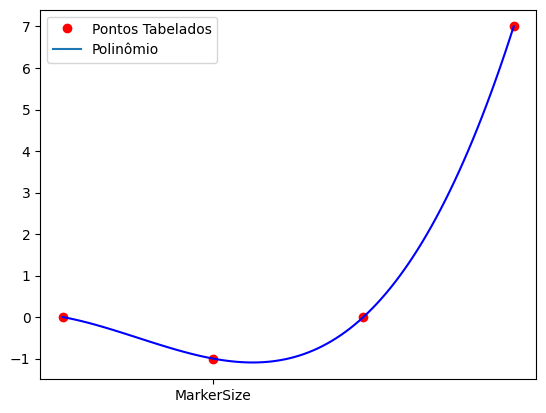

In [12]:
minimos_quadrados(xi, yi, 3)